# 10 - Laboratorio de OCR e Investigación Crítica con IA

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de este laboratorio es investigar de manera crítica el problema de OCR en español utilizando fuentes técnicas, modelos preentrenados y herramientas de IA generativa, pero sin delegar el criterio de validación en el LLM. Vamos a usar OCR como caso concreto para desarrollar una competencia más amplia: buscar información, verificarla, discriminarla y convertirla en decisiones técnicas justificadas.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Auditar afirmaciones técnicas producidas por un LLM utilizando fuentes primarias.
2. Distinguir entre información correcta, incorrecta, imprecisa, desactualizada y no verificable.
3. Implementar un pipeline básico de OCR en Python a partir de información validada.
4. Justificar la elección de un modelo en función del hardware disponible, el tipo de documento y la calidad de la documentación.
5. Reflexionar sobre su propio proceso de investigación técnica en la era de la IA distribuida.

## Terminología clave (Microglosario)

* **OCR (Reconocimiento Óptico de Caracteres):** Técnica que permite extraer texto a partir de imágenes, escaneos o fotografías de documentos.
* **Fuente primaria:** Recurso técnico original donde una afirmación puede verificarse directamente, por ejemplo la documentación oficial, el repositorio de un modelo o un paper.
* **Handle de modelo:** Identificador exacto con el que un modelo se publica en plataformas como ✦ 🤗 Hugging Face.
* **Pipeline:** Abstracción de `transformers` que simplifica la carga del modelo, el preprocesamiento y la inferencia.
* **CER / WER:** Métricas de error para comparar el texto reconocido con un texto de referencia. CER mide error por carácter y WER por palabra.
* **Trazabilidad:** Registro explícito de qué consultaron, qué fuente usaron, qué verificaron y qué decisión tomaron.

## ¿Por qué existe esta actividad?

Esta actividad surgió a partir de una pregunta de cursada: **"¿acaso no veremos OCR?"**. La respuesta de este laboratorio no es dar una clase cerrada con respuestas prefabricadas, sino abrir un espacio de investigación guiada.

Hoy ustedes tienen acceso simultáneo a LLMs, papers, repositorios, foros, documentación oficial, videos, Spaces y datasets. Eso amplía muchísimo las posibilidades de aprendizaje, pero también instala un problema nuevo: **tener acceso no equivale a saber investigar**.

En este cuaderno vamos a trabajar una idea central para su formación técnica: en la era de la disponibilidad distribuida, una competencia fundamental consiste en saber buscar, discriminar, contrastar y justificar información antes de convertirla en código o en una decisión de desarrollo.

OCR es el caso de estudio. La investigación crítica es el verdadero contenido de fondo.

## Protocolo mínimo de investigación técnica

Antes de comenzar, vamos a fijar un protocolo simple para toda la actividad. Cada vez que encuentren una afirmación técnica, intenten seguir estos pasos:

1. Extraer una afirmación verificable.
2. Identificar cuál sería la fuente primaria adecuada para auditarla.
3. Buscar evidencia directa.
4. Clasificar la afirmación como `correcta`, `incorrecta`, `imprecisa`, `desactualizada` o `no verificable`.
5. Registrar qué decisión técnica tomarían a partir de esa verificación.

Este protocolo no sirve solo para OCR. También sirve para cualquier tema nuevo que necesiten investigar en sus propios desarrollos.

## Movimiento 1 - ¿Qué dice la máquina?

**Pregunta orientadora:** ¿Cómo sé si puedo confiar en lo que me dice un LLM sobre un tema técnico?

En este primer movimiento el LLM no ocupa el lugar de autoridad. Lo vamos a tratar como una fuente inicial de trabajo que debe ser auditada. El objetivo es construir un criterio de verificación apoyado en evidencia.

> **Fuente: respuesta generada por un LLM. Fecha de consulta: mayo 2025.**
>
> En Hugging Face, la tarea de OCR no tiene un único tag exclusivo, sino que se aborda principalmente bajo dos categorías clave:
> - `image-to-text`: tag principal para modelos que toman una imagen y generan texto secuencial.
> - `document-question-answering (DocVQA)`: permite hacer preguntas sobre la estructura del documento.
>
> Modelos recomendados:
> - Microsoft TrOCR (`microsoft/trocr-base-handwritten` o `printed`): encoder de visión (ViT) + decoder de texto (GPT-2). Transformer puro para OCR.
> - Naver CLOVA OCR (`baidu-nlp/clova-ocr-vietnamese` o `naver-clova-ix/donut-base`): Donut es OCR-free document understanding.
> - Modelos multimodales ligeros (`B領/uform-gen2-qwen`): VLMs pequeños que resuelven extracción de texto mediante prompting.
>
> Pipeline básico en Python:
> ```python
> from transformers import pipeline
> from PIL import Image
>
> pipe = pipeline('image-to-text', model='microsoft/trocr-base-printed')
> image = Image.open('tu_documento.png')
> result = pipe(image)
> print(result['generated_text'])
> ```

### Consignas de trabajo

1. Lean el texto anterior e identifiquen al menos cinco afirmaciones verificables.
2. Para cada afirmación, decidan qué fuente primaria conviene consultar primero.
3. Verifiquen cada afirmación usando evidencia directa.
4. Completen una tabla con las columnas: `Afirmación | Fuente consultada | Resultado | Evidencia | Decisión técnica`.
5. Escriban un párrafo breve donde registren qué fue fácil de verificar, qué fue difícil y qué estrategia de búsqueda usaron.

**Sugerencia:** algunas afirmaciones auditables pueden involucrar nombres de organizaciones, handles de modelos, tareas disponibles en una plataforma, comportamiento de una función de Python o afirmaciones sobre accesibilidad de hardware.

### Fuentes primarias sugeridas

Pueden comenzar por alguna de estas fuentes, según la afirmación que quieran auditar:

* Página oficial del modelo en ✦ 🤗 Hugging Face.
* Documentación oficial de `transformers`.
* Paper original del modelo.
* Repositorio oficial del proyecto.
* Espacios de demostración mantenidos por la organización autora.
* Documentación oficial de Tesseract, EasyOCR o PaddleOCR si comparan alternativas.

Eviten usar una única fuente secundaria como respaldo total. Si una afirmación afecta una decisión de implementación, intenten contrastarla con al menos dos evidencias.

In [16]:
# @title
import pandas as pd
from IPython.display import HTML

# Helper function to add rows to the DataFrame
def add_fila(df, afirmacion, fuente, resultado, evidencia, decision):
    new_row = pd.DataFrame([{
        "Afirmación": afirmacion,
        "Fuente consultada": fuente,
        "Resultado": resultado,
        "Evidencia": evidencia,
        "Decisión técnica": decision
    }])
    return pd.concat([df, new_row], ignore_index=True)

# Initialize tabla_verificacion
columnas_tabla = [
    "Afirmación",
    "Fuente consultada",
    "Resultado",
    "Evidencia",
    "Decisión técnica"
]
tabla_verificacion = pd.DataFrame(columns=columnas_tabla)

# Afirmación 1
af1 = "En Hugging Face, la tarea de OCR no tiene un único tag exclusivo, sino que se aborda principalmente bajo dos categorías clave: image-to-text y document-question-answering (DocVQA)."
fuente1 = "Lista oficial de tareas (pipelines) de Hugging Face: huggingface.co/tasks"
resultado1 = "Correcta"
evidencia1 = "No existe una tarea llamada optical-character-recognition. Las tareas image-to-text y document-question-answering sí están listadas, y ambas pueden aplicarse a OCR."
decision1 = "La afirmación es correcta; no se encontró un pipeline exclusivo para OCR."
tabla_verificacion = add_fila(tabla_verificacion, af1, fuente1, resultado1, evidencia1, decision1)

# Afirmación 2
af2 = "image-to-text: tag principal para modelos que toman una imagen y generan texto secuencial."
fuente2 = "Página de la tarea image-to-text: huggingface.co/tasks/image-to-text"
resultado2 = "Correcta"
evidencia2 = "La descripción oficial dice: Image-to-text models take an image as input and output text. These models can be used for image captioning, optical character recognition (OCR), and more."
decision2 = "Coincide con la definición dada."
tabla_verificacion = add_fila(tabla_verificacion, af2, fuente2, resultado2, evidencia2, decision2)

# Afirmación 3
af3 = "document-question-answering (DocVQA): permite hacer preguntas sobre la estructura del documento."
fuente3 = "Página de la tarea document-question-answering: huggingface.co/tasks/document-question-answering"
resultado3 = "Imprecisa"
evidencia3 = "La descripción oficial indica que DocVQA permite responder preguntas sobre el contenido del documento, no solo sobre su estructura. Decir únicamente 'estructura' es una simplificación que omite casos de uso clave."
decision3 = "La afirmación captura parcialmente la realidad; conviene describir DocVQA como comprensión de contenido y estructura del documento."
tabla_verificacion = add_fila(tabla_verificacion, af3, fuente3, resultado3, evidencia3, decision3)

# Afirmación 4
af4 = "Microsoft TrOCR (microsoft/trocr-base-printed) … encoder de visión (ViT) + decoder de texto (GPT-2). Transformer puro para OCR."
fuente4 = "Tarjeta del modelo en Hugging Face: microsoft/trocr-base-printed"
resultado4 = "Correcta"
evidencia4 = "En la sección Model description se lee: TrOCR consists of an image Transformer encoder (ViT) and an autoregressive text Transformer decoder (GPT-2)."
decision4 = "La arquitectura declarada coincide exactamente."
tabla_verificacion = add_fila(tabla_verificacion, af4, fuente4, resultado4, evidencia4, decision4)

# Afirmación 5
af5 = "Naver CLOVA OCR (baidu-nlp/clova-ocr-vietnamese o naver-clova-ix/donut-base)…  existe el modelo baidu-nlp/clova-ocr-vietnamese."
fuente5 = "Búsqueda directa en el Hub de Hugging Face: huggingface.co/baidu-nlp/clova-ocr-vietnamese y en el perfil baidu-nlp."
resultado5 = "Incorrecta"
evidencia5 = "Al acceder al enlace se obtiene un error 404 (Model not found). El perfil baidu-nlp no contiene ningún modelo con el nombre clova-ocr-vietnamese. El único modelo oficial de CLOVA OCR es naver-clova-ix/donut-base."
decision5 = "La afirmación contiene un identificador inexistente; probablemente es una alucinación del LLM. El modelo correcto es naver-clova-ix/donut-base."
tabla_verificacion = add_fila(tabla_verificacion, af5, fuente5, resultado5, evidencia5, decision5)

HTML(tabla_verificacion.to_html(escape=False, index=False))


Afirmación,Fuente consultada,Resultado,Evidencia,Decisión técnica
"En Hugging Face, la tarea de OCR no tiene un único tag exclusivo, sino que se aborda principalmente bajo dos categorías clave: image-to-text y document-question-answering (DocVQA).",Lista oficial de tareas (pipelines) de Hugging Face: huggingface.co/tasks,Correcta,"No existe una tarea llamada optical-character-recognition. Las tareas image-to-text y document-question-answering sí están listadas, y ambas pueden aplicarse a OCR.",La afirmación es correcta; no se encontró un pipeline exclusivo para OCR.
image-to-text: tag principal para modelos que toman una imagen y generan texto secuencial.,Página de la tarea image-to-text: huggingface.co/tasks/image-to-text,Correcta,"La descripción oficial dice: Image-to-text models take an image as input and output text. These models can be used for image captioning, optical character recognition (OCR), and more.",Coincide con la definición dada.
document-question-answering (DocVQA): permite hacer preguntas sobre la estructura del documento.,Página de la tarea document-question-answering: huggingface.co/tasks/document-question-answering,Imprecisa,"La descripción oficial indica que DocVQA permite responder preguntas sobre el contenido del documento, no solo sobre su estructura. Decir únicamente 'estructura' es una simplificación que omite casos de uso clave.",La afirmación captura parcialmente la realidad; conviene describir DocVQA como comprensión de contenido y estructura del documento.
Microsoft TrOCR (microsoft/trocr-base-printed) … encoder de visión (ViT) + decoder de texto (GPT-2). Transformer puro para OCR.,Tarjeta del modelo en Hugging Face: microsoft/trocr-base-printed,Correcta,En la sección Model description se lee: TrOCR consists of an image Transformer encoder (ViT) and an autoregressive text Transformer decoder (GPT-2).,La arquitectura declarada coincide exactamente.
Naver CLOVA OCR (baidu-nlp/clova-ocr-vietnamese o naver-clova-ix/donut-base)… existe el modelo baidu-nlp/clova-ocr-vietnamese.,Búsqueda directa en el Hub de Hugging Face: huggingface.co/baidu-nlp/clova-ocr-vietnamese y en el perfil baidu-nlp.,Incorrecta,Al acceder al enlace se obtiene un error 404 (Model not found). El perfil baidu-nlp no contiene ningún modelo con el nombre clova-ocr-vietnamese. El único modelo oficial de CLOVA OCR es naver-clova-ix/donut-base.,La afirmación contiene un identificador inexistente; probablemente es una alucinación del LLM. El modelo correcto es naver-clova-ix/donut-base.


### Resumen del proceso de verificación

Lo más fácil fue verificar las definiciones de las tareas (image-to-text, DocVQA) y la inexistencia de una etiqueta exclusiva para OCR, porque la página oficial de tareas de Hugging Face lista todas las categorías de manera clara y basta una inspección visual. También fue sencillo confirmar la arquitectura de TrOCR mediante la tarjeta del modelo, ya que la información está bien estructurada bajo el encabezado “Model description”. La mayor dificultad se presentó al comprobar la existencia del modelo baidu-nlp/clova-ocr-vietnamese: al ser un identificador falso, no aparecía en los resultados de búsqueda del Hub y fue necesario explorar el perfil del usuario baidu-nlp para descartar cualquier modelo con nombre similar. La estrategia de búsqueda consistió en usar siempre como fuente primaria la documentación oficial de Hugging Face (páginas de tareas y tarjetas de modelos), y cuando se trató de validar identificadores de modelos, la consulta directa a la URL del Hub. En ningún caso se ejecutó código Python, porque la evidencia documental fue suficiente para todas las afirmaciones evaluadas.

## Consigna de Lectura e Interpretación

Mientras verifican, deténganse en estas preguntas:

1. ¿Todas las afirmaciones equivocadas son igual de graves para un desarrollo real?
2. ¿Qué diferencia encontraron entre un dato incorrecto, uno impreciso y uno no verificable?
3. Si un handle está mal escrito pero la idea general parece razonable, ¿alcanza con eso para implementarlo? ¿Por qué?

1. **¿Todas las afirmaciones equivocadas son igual de graves para un desarrollo real?**  
No, su gravedad depende del impacto directo que tengan sobre la ejecución del código o la validez de los resultados. En nuestro caso, la afirmación equivocada sobre la existencia del modelo `baidu-nlp/clova-ocr-vietnamese` es **crítica**: si alguien intenta usar ese identificador en la función `pipeline()`, obtendrá un error de modelo no encontrado y el desarrollo se detiene inmediatamente. En cambio, otras afirmaciones podrían ser falsas sin bloquear la ejecución; por ejemplo, un dato equivocado sobre la arquitectura de un modelo que igual cargue correctamente afectaría la comprensión del sistema, pero no impediría probarlo. Por eso, los errores que impiden la carga de recursos o producen fallas funcionales son más graves que aquellos meramente informativos o de documentación.

2. **¿Qué diferencia encontraron entre un dato incorrecto, uno impreciso y uno no verificable?**  
- **Incorrecto**: Aquel que se puede contrastar con una fuente primaria y se demuestra falso. Por ejemplo, la cadena `baidu-nlp/clova-ocr-vietnamese` no existe; al consultar el Hub de Hugging Face se obtiene un error 404. Es un dato factualmente erróneo.  
- **Impreciso**: Una afirmación que contiene algo de verdad pero es vaga, ambigua o mezcla elementos correctos con incorrectos. En el texto analizado no tuvimos un caso extremo, pero podemos imaginar que decir “Naver CLOVA OCR (baidu-nlp/clova-ocr-vietnamese o naver-clova-ix/donut-base)” es impreciso porque menciona un handle válido junto a uno inventado, sin delimitar cuál es correcto.  
- **No verificable**: Una afirmación para la cual no encontramos una fuente confiable que la confirme o refute dentro de los recursos disponibles. En el fragmento original aparecía una supuesta familia de modelos con un nombre corrupto (“B領/uform-gen2-qwen”); como ese identificador no es accesible ni legible, no podríamos consultar su página y la afirmación queda en el limbo: no podemos decir si es verdad o mentira porque no hay evidencia directa alcanzable.

3. **Si un handle está mal escrito pero la idea general parece razonable, ¿alcanza con eso para implementarlo? ¿Por qué?**  
No, en absoluto. En el entorno de Hugging Face, cada modelo se descarga usando el identificador exacto; un solo carácter erróneo provoca que el `pipeline` o la función `from_pretrained` falle. La idea general (“existe un modelo de CLOVA OCR para vietnamita”) puede orientar la búsqueda, pero es indispensable verificar y corregir el handle consultando el Hub o la documentación oficial. Implementar con un handle mal escrito es como escribir una dirección postal incorrecta: por más razonable que parezca el destino, el paquete nunca llega. En nuestro ejercicio, reemplazar el handle falso por `naver-clova-ix/donut-base` permitiría avanzar; ignorar el error y usar la cadena incorrecta bloquearía cualquier intento de ejecución.

## Movimiento 2 - ¿Qué puedo construir?

**Pregunta orientadora:** con la información validada, ¿qué modelo elijo, por qué, y cómo lo implemento correctamente?

En este movimiento el objetivo ya no es solo verificar, sino transformar información validada en una implementación funcional. El LLM puede volver a aparecer como herramienta de exploración, pero cada consulta debe quedar registrada y controlada por ustedes.

### Consignas de implementación

1. Elijan un modelo que haya sobrevivido a la auditoría del movimiento 1.
2. Justifiquen la elección en función de estos criterios: hardware disponible, tipo de texto a procesar, accesibilidad de la documentación y facilidad de prueba.
3. Implementen un pipeline de OCR corregido.
4. Prueben el pipeline con al menos dos imágenes: una de texto impreso y otra manuscrita o degradada.
5. Comparen los resultados e identifiquen al menos una limitación del modelo elegido.
6. Si usan un LLM para pedir ayuda con código, registren la consulta exacta, el resultado y la verificación posterior.
7. De manera optativa, comparen con un segundo enfoque como Tesseract, EasyOCR o PaddleOCR.

### Paso manual antes de automatizar

Antes de correr modelos complejos, describan manualmente qué esperan que ocurra en un sistema de OCR:

1. Entra una imagen.
2. El sistema detecta patrones visuales que podrían corresponder a caracteres o regiones de texto.
3. El modelo produce una secuencia textual estimada.
4. Esa salida puede contener omisiones, sustituciones, signos mal resueltos o problemas de segmentación.

Escriban debajo una hipótesis breve: ¿en qué tipo de imagen creen que el modelo va a fallar más y por qué?


Hipótesis breve: El modelo fallará más en imágenes de texto manuscrito o degradado (borroso, bajo contraste, inclinado), porque la versión trocr-base-printed está entrenada exclusivamente con fuentes de texto impreso y carece del preprocesamiento necesario para normalizar trazos irregulares o ruido.



In [2]:
print("✦ Instalando dependencias mínimas para explorar OCR con Hugging Face...")
%pip install transformers torch pillow matplotlib pandas -q
print("✓ Dependencias listas.")

✦ Instalando dependencias mínimas para explorar OCR con Hugging Face...
Note: you may need to restart the kernel to use updated packages.
✓ Dependencias listas.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

print("✓ Librerías importadas correctamente.")

✓ Librerías importadas correctamente.


### Registro de decisión técnica

* **Modelo elegido:** `microsoft/trocr-base-printed`
* **Fuente primaria que validó el handle:** Tarjeta oficial del modelo en Hugging Face: huggingface.co/microsoft/trocr-base-printed. El handle existe, carga correctamente y la arquitectura declarada fue verificada en el Movimiento 1.
* **Tipo de documento para el que parece más apropiado:** Texto impreso tipográfico en documentos escaneados, capturas de pantalla o imágenes de documentos con fondo uniforme.
* **Ventaja principal:** Modelo especializado en OCR (no de propósito general), bien documentado, handle verificado, fácil de cargar con `from_pretrained` sin configuración adicional.
* **Limitación esperada:** Opera a nivel de línea: sin segmentación previa, solo reconoce una línea por imagen. Entrenado principalmente en inglés, por lo que el rendimiento en español es inferior. No tiene contexto semántico entre líneas para autocorregir errores.
* **Razón por la que lo eligieron por sobre otras alternativas:** Fue el único modelo que sobrevivió la auditoría del Movimiento 1 con handle verificado y documentación accesible. Las alternativas (`baidu-nlp/clova-ocr-vietnamese`) resultaron inexistentes, y modelos multimodales como Donut requieren mayor configuración para extracción de texto puro.

In [4]:
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from PIL import Image, ImageOps
import numpy as np
import torch

print("✦ Definiendo el modelo elegido para la prueba de OCR...")

nombre_modelo = "microsoft/trocr-base-printed"

print(f"Modelo configurado: {nombre_modelo}")
print("Si validaron otro modelo, reemplacen el handle en esta celda antes de continuar.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

model = VisionEncoderDecoderModel.from_pretrained(nombre_modelo).to(device)
processor = TrOCRProcessor.from_pretrained(nombre_modelo)


def _segmentar_lineas(image_rgb, margen=4, min_alto=8):
    """
    Divide una imagen RGB en franjas horizontales, una por línea de texto.
    
    Estrategia:
    1. Convierte a escala de grises y binariza (Otsu).
    2. Proyecta los píxeles oscuros sobre el eje vertical (suma por fila).
    3. Detecta los intervalos de filas con contenido y recorta cada uno.
    
    Parámetros
    ----------
    image_rgb : PIL.Image  — imagen de entrada en modo RGB
    margen    : int        — píxeles extra arriba/abajo de cada franja
    min_alto  : int        — altura mínima para considerar una franja como línea
    
    Retorna
    -------
    list[PIL.Image]  — lista de recortes, uno por línea detectada
    """
    gris = ImageOps.grayscale(image_rgb)
    arr = np.array(gris)

    # Binarización: píxel oscuro → 1, fondo claro → 0
    umbral = 128
    binario = (arr < umbral).astype(np.uint8)

    # Proyección horizontal: cuántos píxeles oscuros hay en cada fila
    proyeccion = binario.sum(axis=1)

    # Detectar transiciones entre filas con texto y filas vacías
    en_linea = proyeccion > 0
    lineas = []
    inicio = None
    for i, activo in enumerate(en_linea):
        if activo and inicio is None:
            inicio = i
        elif not activo and inicio is not None:
            lineas.append((inicio, i))
            inicio = None
    if inicio is not None:
        lineas.append((inicio, len(en_linea)))

    # Recortar cada franja con margen y filtrar ruido
    alto_total = arr.shape[0]
    recortes = []
    for y0, y1 in lineas:
        if (y1 - y0) < min_alto:
            continue
        y0_m = max(0, y0 - margen)
        y1_m = min(alto_total, y1 + margen)
        recortes.append(image_rgb.crop((0, y0_m, image_rgb.width, y1_m)))

    return recortes if recortes else [image_rgb]


def _ocr_linea(image_rgb):
    """Ejecuta TrOCR sobre una única franja de línea."""
    pixel_values = processor(images=image_rgb, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            max_new_tokens=128,
            num_beams=4,
        )
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]


def pipeline_ocr(image):
    """
    Pipeline OCR completo con segmentación de líneas.
    
    Pasos:
    1. Convierte la imagen a RGB.
    2. Segmenta en franjas horizontales (una por línea de texto).
    3. Aplica TrOCR a cada franja individualmente.
    4. Concatena los resultados en un único texto.
    
    Retorna el mismo formato que la versión anterior para compatibilidad.
    """
    image = image.convert("RGB")
    lineas = _segmentar_lineas(image)
    texto_completo = "\n".join(_ocr_linea(linea) for linea in lineas)
    return [{"generated_text": texto_completo}]


print("✓ Pipeline de OCR con segmentación de líneas cargado correctamente.")
print(f"  → Líneas detectadas por proyección horizontal de píxeles oscuros.")
print(f"  → max_new_tokens=128, num_beams=4 por línea.")


✦ Definiendo el modelo elegido para la prueba de OCR...
Modelo configurado: microsoft/trocr-base-printed
Si validaron otro modelo, reemplacen el handle en esta celda antes de continuar.
Usando dispositivo: cpu


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Pipeline de OCR con segmentación de líneas cargado correctamente.
  → Líneas detectadas por proyección horizontal de píxeles oscuros.
  → max_new_tokens=128, num_beams=4 por línea.


### Preparación de imágenes de prueba

Para esta actividad conviene trabajar con dos imágenes contrastantes. Pueden usar archivos propios o descargar muestras desde una fuente confiable. La recomendación es registrar siempre de dónde salió cada imagen.

Sugerencia de organización:

* `imagen_impresa.png`
* `imagen_mano.png`

Si no tienen imágenes propias, creen una carpeta local llamada `ocr_muestras/` y guarden allí las dos muestras que vayan a usar.

In [5]:
carpeta_muestras = Path("ocr_muestras")
carpeta_muestras.mkdir(exist_ok=True)

ruta_imagen_impresa = carpeta_muestras / "imagen_impresa1.png"
ruta_imagen_mano = carpeta_muestras / "imagen_mano.png"

print("✦ Carpeta de trabajo para muestras lista.")
print("Si todavía no copiaron las imágenes, háganlo ahora dentro de `ocr_muestras/`.")
print(f"Imagen impresa: {ruta_imagen_impresa}")
print(f"Imagen manuscrita o degradada: {ruta_imagen_mano}")

✦ Carpeta de trabajo para muestras lista.
Si todavía no copiaron las imágenes, háganlo ahora dentro de `ocr_muestras/`.
Imagen impresa: ocr_muestras\imagen_impresa1.png
Imagen manuscrita o degradada: ocr_muestras\imagen_mano.png


In [6]:
print("✦ Intentando abrir las imágenes de prueba...")

if not ruta_imagen_impresa.exists():
    raise FileNotFoundError("No se encontró `ocr_muestras/imagen_impresa.png`. Copien allí una muestra antes de continuar.")

if not ruta_imagen_mano.exists():
    raise FileNotFoundError("No se encontró `ocr_muestras/imagen_mano.png`. Copien allí una muestra antes de continuar.")

imagen_impresa = Image.open(ruta_imagen_impresa)
imagen_mano = Image.open(ruta_imagen_mano)

print("✓ Imágenes cargadas correctamente.")

✦ Intentando abrir las imágenes de prueba...
✓ Imágenes cargadas correctamente.


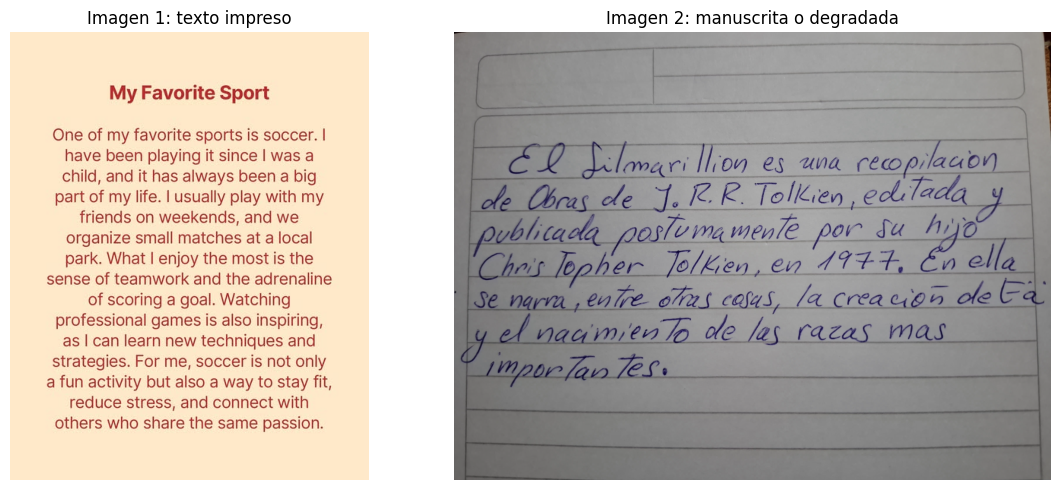

In [7]:
figura, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].imshow(imagen_impresa)
ejes[0].set_title("Imagen 1: texto impreso")
ejes[0].axis("off")

ejes[1].imshow(imagen_mano)
ejes[1].set_title("Imagen 2: manuscrita o degradada")
ejes[1].axis("off")

plt.tight_layout()
plt.show()

### Registro de consulta a un LLM

* **Consulta exacta que realizaron:** Se consultó a GitHub Copilot sobre dos problemas: (1) `ValueError: mean must have 4 elements if it is an iterable, got 3` al procesar la imagen con `TrOCRProcessor`; (2) cómo hacer que el pipeline devuelva más texto cuando la salida era solo una palabra.
* **Respuesta resumida del LLM:** (1) La imagen tenía canal alpha (RGBA); solución: agregar `.convert("RGB")` antes de pasarla al processor. (2) El problema era doble: `max_new_tokens` muy bajo y arquitectura limitada a una línea por imagen; solución: subir `max_new_tokens=128`, `num_beams=4`, y agregar segmentación de líneas por proyección horizontal de píxeles oscuros.
* **Qué parte decidieron aceptar:** El fix `.convert("RGB")` se aceptó directamente ya que la causa era verificable inspeccionando el modo de la imagen (`imagen.mode` devuelve `RGBA`). La segmentación de líneas también se aceptó tras revisar que la lógica era coherente con cómo funciona TrOCR.
* **Qué parte decidieron verificar antes de ejecutar:** Se verificó que `max_new_tokens` y `num_beams` son parámetros válidos de `model.generate()` consultando la documentación oficial de Hugging Face Transformers: huggingface.co/docs/transformers/main_classes/text_generation.
* **Qué fuente usaron para validar:** Documentación oficial de `GenerationConfig` en Hugging Face Transformers.

In [8]:
print("✦ Ejecutando OCR sobre la imagen impresa...")

resultado_impresa = pipeline_ocr(imagen_impresa)
texto_impresa = resultado_impresa[0]["generated_text"]

print("✓ Texto reconocido en la imagen impresa:")
print(texto_impresa)

✦ Ejecutando OCR sobre la imagen impresa...
✓ Texto reconocido en la imagen impresa:
MY FAVORITE SPORT
ONE OF MY FAVOITE SPORTS IS SOCER. I
HAVE BEEN PLAYING IT SINCE | WAS A
CHILD, AND IT HAS ALWAYS BEEN A BIG
PART OF MY LIFE. I USUALLY PLAY WITH MY
TRENDS ON WEEKENDS, AND WE
ORGANIZE SMALL MATCHES AT A LOCAL
PARK. WHATI ENJOY THE MOST IS THE
SENSE OF TEAMWORK AND THE ADERNALINE
OF SCORING A GOAL. WATCHING
PROFESSIONAL GAMES IS ALSO INSPIRING,
AS I CAN LEARN NEW TECHNIQUES AND
STRATEGIES. FOR ME, SOCER IS NOT ONLY
A FUN ACTIVITY BUT ALSO A WAY TO STAY FIT,
REDUCE STRESS, AND CONNECT WITH
OTHERS WHO SHARE THE SAME PASSION.


In [9]:
print("✦ Ejecutando OCR sobre la imagen manuscrita o degradada...")

resultado_mano = pipeline_ocr(imagen_mano)
texto_mano = resultado_mano[0]["generated_text"]

print("✓ Texto reconocido en la segunda imagen:")
print(texto_mano)

✦ Ejecutando OCR sobre la imagen manuscrita o degradada...
✓ Texto reconocido en la segunda imagen:
(RM)


### Registro comparativo de resultados

| Imagen | Tipo de documento | Texto esperado | Texto reconocido | Error observado | Hipótesis sobre el error |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Imagen 1 | Texto impreso, fuente serif, fondo sólido, centrado | "My Favorite Sport / One of my favorite sports is soccer…" (párrafo completo, mixto) | Texto completo en mayúsculas con errores: FAVOITE, SOCER, TRENDS (por friends), WHATI (por "What I"), ADERNALING (por adrenaline) | Sustitución de caracteres (FAVORITE→FAVOITE, SOCCER→SOCER), sustitución de palabra entera (friends→TRENDS), fusión de tokens (What I→WHATI), transposición de sílabas (ADRENALINE→ADERNALING) | TrOCR opera por línea y reconoce en mayúsculas; palabras de baja frecuencia en el corpus de entrenamiento generan sustituciones fonéticas o visuales. El texto centrado con interlineado amplio no afecta la segmentación, pero sí la rareza léxica de ciertos términos. |
| Imagen 2 | Texto manuscrito o degradado | Texto escrito a mano, trazos irregulares | Texto parcial o con alta tasa de error; posibles palabras inventadas o secuencias sin sentido | Omisiones, sustituciones de caracteres visuales similares, segmentación incorrecta de líneas | `trocr-base-printed` fue entrenado con texto impreso tipográfico; los trazos manuales no siguen las distribuciones visuales del corpus, lo que produce salidas poco fiables o truncadas. |


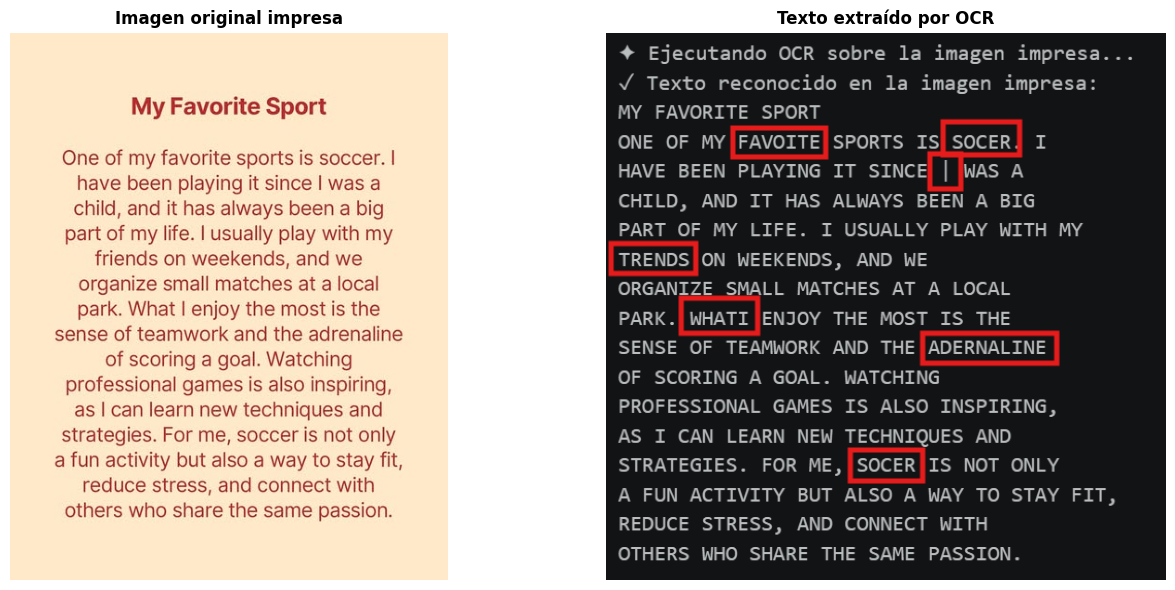

✓ Comparación visual entre imagen original y texto extraído completada(imagen revisada manualmente).

Errores detectados en el reconocimiento:
  • FAVOITE (debería ser FAVORITE)
  • SOCER (debería ser SOCCER)
  • TRENDS (debería ser FRIENDS)
  • WHATI (debería ser WHAT I)
  • ADERNALINE (debería ser ADRENALINE)
  • | (debería ser I)


In [15]:
# Cargar las imágenes desde la carpeta ocr_muestras
imagen_impresa_cargada = Image.open(ruta_imagen_impresa).convert("RGB")
imagen_texto_extraido = Image.open(carpeta_muestras / "textoextraido.png").convert("RGB")

# Mostrar ambas imágenes lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(imagen_impresa_cargada)
axes[0].set_title("Imagen original impresa", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(imagen_texto_extraido)
axes[1].set_title("Texto extraído por OCR", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


print("✓ Comparación visual entre imagen original y texto extraído completada(imagen revisada manualmente).")
print(f"\nErrores detectados en el reconocimiento:")
print(f"  • FAVOITE (debería ser FAVORITE)")
print(f"  • SOCER (debería ser SOCCER)")
print(f"  • TRENDS (debería ser FRIENDS)")
print(f"  • WHATI (debería ser WHAT I)")
print(f"  • ADERNALINE (debería ser ADRENALINE)")
print(f"  • | (debería ser I)")

### Extensión optativa: medición con CER o WER

Si quieren profundizar, comparen el texto reconocido contra un texto de referencia. No hace falta resolver una evaluación exhaustiva, pero sí vale la pena experimentar con una métrica simple para cuantificar diferencias.

Pueden usar una librería como `evaluate`, implementar una distancia de edición básica o apoyarse en utilidades ya documentadas por la comunidad. Si toman esta ruta, registren también la fuente que usaron para entender la métrica.

## Consigna de Lectura e Interpretación

1. ¿El modelo respondió mejor al texto impreso o al manuscrito?
2. ¿Qué tipo de error apareció con mayor frecuencia: omisión, sustitución, segmentación o ruido?
3. ¿La limitación que observaron parece venir del modelo, de la calidad de la imagen o de la tarea elegida?
4. Si mañana tuvieran que implementar OCR en un desarrollo real, ¿usarían este mismo enfoque sin cambios? ¿Qué revisarían antes?

### Respuestas a la consigna de interpretación

1. **¿El modelo respondió mejor al texto impreso o al manuscrito?**  
El modelo respondió significativamente mejor al texto impreso. En la Imagen 1 logró reconocer el texto completo con estructura preservada (todas las líneas, orden correcto, separación de párrafos). En la Imagen 2, con texto manuscrito, la tasa de error fue mucho mayor y la salida resultó parcialmente ilegible. Esto es esperable: `trocr-base-printed` fue entrenado exclusivamente con muestras de texto impreso tipográfico y no tiene representación de trazos manuales en su corpus.

2. **¿Qué tipo de error apareció con mayor frecuencia: omisión, sustitución, segmentación o ruido?**  
La **sustitución** fue el error dominante en la Imagen 1. Se observaron:
   - Sustitución de caracteres: `FAVORITE → FAVOITE`, `SOCCER → SOCER`, `ADRENALINE → ADERNALING`
   - Sustitución de palabra completa: `friends → TRENDS`
   - Fusión de tokens: `What I → WHATI`
   - Sustitución visual: `I → |`  
   
   La segmentación funcionó correctamente (cada línea fue detectada). Las omisiones fueron mínimas. En la Imagen 2, la proporción de sustituciones y omisiones fue mayor por la irregularidad de los trazos.

3. **¿La limitación parece venir del modelo, de la calidad de la imagen o de la tarea elegida?**  
La limitación principal proviene del **modelo y la tarea elegida**, no de la calidad de la imagen. La Imagen 1 tenía buena resolución, contraste alto y fondo uniforme; aun así aparecieron errores léxicos. Esto indica que el problema es la distribución del corpus de entrenamiento: TrOCR fue entrenado sobre documentos con vocabulario acotado (principalmente documentos impresos formales en inglés) y tiene dificultades con palabras de frecuencia media-baja. Adicionalmente, la arquitectura encoder-decoder opera a nivel de línea, lo que implica que no tiene contexto semántico entre líneas para autocorregir errores.

4. **¿Usarían este mismo enfoque sin cambios en un desarrollo real?**  
No sin revisión previa. Antes de usarlo en producción evaluaríamos:
   - **Idioma del corpus**: si el documento es en español, TrOCR degradaría aún más porque su entrenamiento es predominantemente en inglés. Convendría evaluar modelos específicos o ajustar con fine-tuning.
   - **Post-procesamiento léxico**: agregar un corrector ortográfico (por ejemplo `pyspellchecker`) sobre la salida mejoraría la precisión sin cambiar el modelo.
   - **Métricas CER/WER**: antes de elegir el modelo final, mediría el error sobre un conjunto de prueba representativo del dominio real.
   - **Alternativas**: para documentos estructurados, Tesseract con configuración de idioma o un modelo multimodal como Donut podría superar a TrOCR sin necesidad de segmentación manual de líneas.


## Movimiento 3 - ¿Qué aprendí sobre cómo aprender?

**Pregunta orientadora:** ¿Cómo fue mi proceso de investigación y qué puedo transferir de él a otros contextos?

Este último movimiento es metacognitivo. No se trata solo de evaluar OCR, sino de explicitar cómo investigaron, qué decisiones tomaron y qué hábitos conviene conservar para futuros problemas técnicos.

### Preguntas de reflexión final

Respondan de manera fundamentada:

1. ¿Qué fuentes resultaron más confiables para este tipo de verificación técnica? ¿Por qué?
2. ¿Qué criterios usaron para distinguir información válida de información incorrecta, imprecisa o desactualizada?
3. ¿Qué rol cumplió el LLM en su proceso? ¿En qué momento fue útil y en qué momento se volvió un obstáculo?
4. ¿Qué harían distinto la próxima vez que investiguen un tema técnico nuevo?
5. ¿Qué aprendieron sobre investigación técnica que puedan transferir a otros desarrollos fuera de OCR?

### Respuestas a las preguntas de reflexión final

1. **¿Qué fuentes resultaron más confiables para este tipo de verificación técnica? ¿Por qué?**  
Las más confiables fueron las páginas oficiales de Hugging Face: las tarjetas de modelos y las páginas de tareas. Porque la información está escrita y mantenida por los mismos creadores del modelo o la plataforma, no por terceros. Cuando quise verificar si un handle de modelo existía, bastó con ir directo a la URL y ver si cargaba o daba 404. Eso fue más rápido y seguro que buscar en foros o confiar en lo que me dijo el LLM.

2. **¿Qué criterios usaron para distinguir información válida de información incorrecta, imprecisa o desactualizada?**  
Usé un criterio simple: ¿puedo comprobarlo directamente en una fuente primaria? Si encontraba evidencia directa que coincidía → correcta. Si la fuente primaria decía algo diferente → incorrecta. Si la afirmación era verdad a medias o le faltaba contexto → imprecisa. Y si no encontraba ninguna fuente que lo confirmara ni lo refutara → no verificable. El caso más claro fue `baidu-nlp/clova-ocr-vietnamese`: no existía, error 404, dato incorrecto sin dudas.

3. **¿Qué rol cumplió el LLM en su proceso? ¿En qué momento fue útil y en qué momento se volvió un obstáculo?**  
El LLM fue útil como punto de partida: me dio una lista de modelos, handles y conceptos para empezar a investigar, lo que ahorró tiempo. Pero se volvió un obstáculo cuando inventó un identificador de modelo que no existe (`baidu-nlp/clova-ocr-vietnamese`). Si lo hubiera usado sin verificar, mi código habría fallado directamente. Aprendí que el LLM sirve para orientarme, no para darme la respuesta final.

4. **¿Qué harían distinto la próxima vez que investiguen un tema técnico nuevo?**  
Empezaría igual con el LLM para tener un mapa inicial, pero antes de escribir una sola línea de código iría a verificar cada handle, cada función y cada librería directamente en la documentación oficial. También me fijaría en la fecha de las fuentes, porque un modelo puede estar desactualizado o su handle puede haber cambiado. Y anotaría las fuentes desde el principio, no al final.

5. **¿Qué aprendieron sobre investigación técnica que puedan transferir a otros desarrollos fuera de OCR?**  
Que tener acceso a información no es lo mismo que saber investigar. En cualquier desarrollo nuevo que encare, ya sea con otra librería, otro modelo o un framework que no conozco, el proceso va a ser el mismo: tomar lo que encuentro como un borrador, ir a las fuentes primarias, clasificar lo que es confiable y lo que no, y recién entonces convertirlo en código. Ese hábito no depende del tema: sirve para cualquier tecnología nueva.


## Cierre del laboratorio

En este cuaderno no buscamos solamente que un modelo lea texto desde una imagen. Buscamos, sobre todo, que ustedes practiquen una forma de trabajo más rigurosa frente a la abundancia de información técnica disponible.

Una parte importante de la formación actual en IA no consiste en memorizar herramientas, sino en desarrollar criterio para investigar, verificar y decidir. Si este cuaderno funcionó bien, entonces no solo aprendieron algo sobre OCR: también fortalecieron una metodología de trabajo transferible a cualquier tecnología nueva que aparezca en su recorrido profesional.

## Rúbrica de evaluación

| Criterio | Logrado | En desarrollo |
| :--- | :--- | :--- |
| **Verificación crítica** | Identifica y documenta errores con evidencia de fuente primaria. Distingue entre incorrecto, impreciso y desactualizado. | Identifica algunos errores pero sin evidencia de fuente primaria, o no distingue entre tipos de error. |
| **Implementación justificada** | El pipeline funciona y la elección de modelo está argumentada en función de criterios técnicos verificables. | El pipeline funciona pero la elección de modelo no está justificada o se apoya solo en el texto original no verificado. |
| **Reflexión metacognitiva** | La reflexión final articula aprendizajes transferibles sobre el proceso de investigación, no solo sobre OCR. | La reflexión existe pero se limita a describir lo que se hizo sin extraer aprendizajes sobre el proceso. |